In [ ]:
# ============================================================
# STEP 1 — INSTALL DEPENDENCIES
# ============================================================
!pip install kagglehub tensorflow scikit-learn nltk emoji contractions

import numpy as np
import pandas as pd
import re
import string
import nltk
import emoji
import contractions
import tensorflow as tf

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, Layer
)
from tensorflow.keras.models import Model


# ============================================================
# STEP 2 — DOWNLOAD DATASET (Sentiment140)
# ============================================================
import kagglehub

path = kagglehub.dataset_download("kazanova/sentiment140")
file_path = path + "/training.1600000.processed.noemoticon.csv"

columns = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv(file_path, encoding="latin-1", names=columns)
df = df[['target', 'text']]

# Convert labels: 4 → 1 (positive), 0 stays 0 (negative)
df['target'] = df['target'].replace(4, 1)


# ============================================================
# STEP 3 — TEXT PREPROCESSING
# ============================================================
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = emoji.demojize(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    # keep negation words
    words = [w for w in words if w not in stop_words or w in ["not", "no", "nor"]]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)


# ============================================================
# STEP 4 — TRAIN TEST SPLIT
# ============================================================
X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ============================================================
# STEP 5 — TOKENIZATION
# ============================================================
MAX_WORDS = 50000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')


# ============================================================
# STEP 6 — DOWNLOAD & LOAD GLOVE
# ============================================================
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector


# ============================================================
# STEP 7 — BUILD EMBEDDING MATRIX (FIXED)
# ============================================================
EMBEDDING_DIM = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec


# ============================================================
# STEP 8 — ATTENTION LAYER
# ============================================================
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )

    def call(self, inputs):
        score = tf.matmul(inputs, self.W)
        weights = tf.nn.softmax(score, axis=1)
        context = weights * inputs
        return tf.reduce_sum(context, axis=1)


# ============================================================
# STEP 9 — BiLSTM + ATTENTION MODEL
# ============================================================
input_layer = Input(shape=(MAX_LEN,))

embedding_layer = Embedding(
    input_dim=len(word_index) + 1,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
)(input_layer)

bilstm = Bidirectional(LSTM(128, return_sequences=True))(embedding_layer)
attention = Attention()(bilstm)
dropout = Dropout(0.3)(attention)
dense = Dense(64, activation='relu')(dropout)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ============================================================
# STEP 10 — TRAIN MODEL
# ============================================================
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=1,
    batch_size=256
)


# ============================================================
# STEP 11 — EVALUATION
# ============================================================
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ============================================================
# STEP 12 — PREDICTION FUNCTION
# ============================================================
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    pred = model.predict(pad)[0][0]
    return "Positive" if pred > 0.5 else "Negative"


# TEST
print(predict_sentiment("I love this product, it is amazing!"))
print(predict_sentiment("This is the worst experience ever"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
Using Colab cache for faster access to the 'sentiment140' dataset.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--2026-05-28 18:57:31--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-28 18:57:31--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-28 18:57:31--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │    36,700,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,951,765 (140.96 MB)

 Trainable params: 36,951,765 (140.96 MB)

 Non-trainable params: 0 (0.00 B)

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9242s 2s/step - accuracy: 0.7972 - loss: 0.4348 - val_accuracy: 0.8105 - val_loss: 0.4117
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 910s 91ms/step
Accuracy: 0.810453125

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.81    160000
           1       0.81      0.80      0.81    160000

    accuracy                           0.81    320000
   macro avg       0.81      0.81      0.81    320000
weighted avg       0.81      0.81      0.81    320000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Negative


Confusion Matrix:

[[132620  27380]
 [ 39889 120111]]


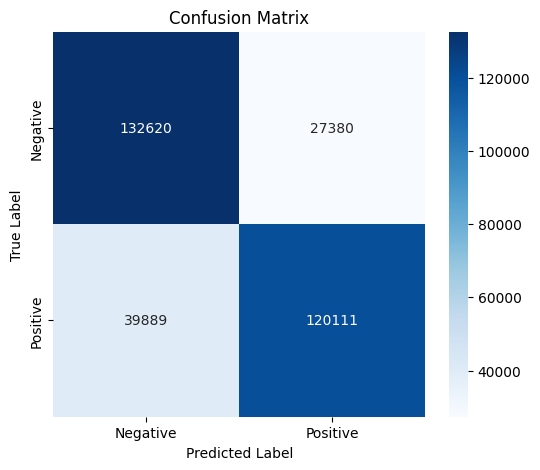

In [ ]:
# ============================================================
# STEP 13 — CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display matrix values
print("Confusion Matrix:\n")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()